# ex006: 各手法の学習効率・対戦強度の総合比較と対人対戦(Human vs AI)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yryo1005/TicTacToe_Reinforcement_Learning_training/blob/main/ex006_comparison_and_play.ipynb)

ex001〜ex005の学習結果を読み込み，5手法を横断的に比較する．あわせて「最適な後手」を構築し，対人対戦の機能も実装する．

理論的な背景・実験条件・考察・発展課題は [ex006_comparison_and_play.md](ex006_comparison_and_play.md) を参照．

## 共通コンポーネント

環境(`TicTacToeEnv`)・エージェント(`BaseAgent`系のクラス)・評価関数(`evaluate`, `play_human_vs_ai`)・ロガー(`ResultLogger`)の実装．全実験(ex001〜ex006)で共通である．

**以下のセルはex001と実装が同一である(変更なし)．Colabではフォームとして折りたたんであり，タイトルをクリックすると展開できる(VS Code等では折りたたまれずに表示される場合がある)．**

必要なライブラリをインポートし，グラフの日本語フォントを設定した上で，乱数シードを固定する`set_seed`関数を定義する．

In [1]:
#@title 共通コード: インポート・日本語フォント設定・set_seed（ex001と同じ実装）
import os
import json
import random
import time
import subprocess
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# グラフ中の日本語(軸ラベル・タイトル等)を正しく表示するため, 日本語フォント(IPAexGothic)を
# 使用する. Google Colabの標準イメージには日本語フォントが含まれていないため, 見つからない
# 場合はaptで補い, フォントキャッシュを再構築してから設定する(失敗しても実行は継続する).
if "IPAexGothic" not in {f.name for f in fm.fontManager.ttflist}:
    try:
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-ipaexfont-gothic"],
            check=False, capture_output=True,
        )
        fm.fontManager.addfont(
            "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
        )
    except Exception:
        pass
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False


def set_seed(seed: int = 0) -> None:
    """
    実験の再現性を確保するため, Python標準のrandomおよびNumPyの乱数シードを固定する.

    引数:
        seed (int): 固定する乱数シード値. デフォルトは0.
    戻り値:
        なし.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


学習曲線などの指標をメモリ上に記録し，JSONファイルとして保存・読込する`ResultLogger`クラスを定義する．

In [2]:
#@title 共通コード: ResultLoggerクラス（ex001と同じ実装）
class ResultLogger:
    """
    学習中の各種指標(勝率, 価値関数の差分など)の推移をメモリ上に記録し,
    JSONファイルとして保存・読み込みを行う軽量なロガークラス.
    """

    def __init__(self, target_path: str = None):
        """
        引数:
            target_path (str): 既存のログファイルのパス. Noneの場合は新規に初期化する.
        戻り値:
            なし.
        """
        self.names = None
        self.history = {}
        if target_path:
            self.load(target_path)

    def set_names(self, *names: str) -> None:
        """
        記録する指標の名前を登録する.

        引数:
            *names (str): 記録したい指標名(例: "win_rate", "delta").
        戻り値:
            なし.
        """
        if self.names:
            raise ValueError("names はすでに設定されています.")
        self.names = list(names)
        for name in self.names:
            if name not in self.history:
                self.history[name] = []

    def __call__(self, *values) -> None:
        """
        指標の値を履歴に追加する.

        引数:
            *values (float | int): set_namesで登録した順序に対応する値.
        戻り値:
            なし.
        """
        if self.names is None:
            raise ValueError("先に set_names を実行してください.")
        if len(values) != len(self.names):
            raise ValueError("valuesの個数がnamesの個数と一致しません.")
        for name, value in zip(self.names, values):
            self.history[name].append(value)

    def save(self, target_path: str) -> None:
        """
        記録された履歴をJSONファイルとして保存する.

        引数:
            target_path (str): 保存先のファイルパス.
        戻り値:
            なし.
        """
        os.makedirs(os.path.dirname(target_path), exist_ok=True)
        with open(target_path, "w") as f:
            json.dump(self.history, f, indent=4, ensure_ascii=False)

    def load(self, target_path: str) -> None:
        """
        保存されたJSONファイルから履歴データを読み込む.

        引数:
            target_path (str): 読み込むファイルパス.
        戻り値:
            なし.
        """
        with open(target_path, "r") as f:
            data = json.load(f)
        self.history = data
        self.names = list(data.keys())

    def __getitem__(self, key: str):
        """
        引数:
            key (str): 指標名.
        戻り値:
            list: 履歴リスト. 存在しない場合は空リスト.
        """
        return self.history.get(key, [])


3目並べの環境クラス`TicTacToeEnv`を定義する．盤面の初期化，行動の実行，勝敗判定に加え，動的計画法で使う遷移確率の計算・状態の列挙も行う．

In [3]:
#@title 共通コード: TicTacToeEnv環境クラス（ex001と同じ実装）
class TicTacToeEnv:
    """
    3目並べの環境クラス.

    学習エージェントは常に先手(X, セル値1)とし, 後手(O, セル値2)は
    合法手から一様ランダムに選択する固定方策に従う「環境の一部」として扱う.
    この定式化により, 方策反復法・価値反復法が要求する既知の遷移確率 p(s'|s,a) を
    ゲーム規則から解析的に計算できる1エージェント視点のMDPとなる.

    状態は盤面9マスをタプルで表現し, 各要素は 0(空), 1(X), 2(O) を取る.
    状態ID (state_id) は3進数エンコード state_id = Σ_i board[i]・3^i (0 <= state_id < 3^9)
    により, NumPy配列のインデックスとして利用できる整数に変換したものである.
    """

    EMPTY, X, O = 0, 1, 2
    N_CELLS = 9
    N_STATES = 3 ** 9
    LINES = [
        (0, 1, 2), (3, 4, 5), (6, 7, 8),
        (0, 3, 6), (1, 4, 7), (2, 5, 8),
        (0, 4, 8), (2, 4, 6),
    ]

    def __init__(self, opponent_seed: int = None):
        """
        引数:
            opponent_seed (int): 後手(固定ランダム方策)の乱数シード.
        戻り値:
            なし.
        """
        self.rng = np.random.default_rng(opponent_seed)
        self.board = None

    def reset(self) -> tuple:
        """
        盤面を空の状態に初期化する.

        引数:
            なし.
        戻り値:
            tuple[int]: 初期状態(長さ9, 全て空).
        """
        self.board = tuple([self.EMPTY] * self.N_CELLS)
        return self.board

    @classmethod
    def get_valid_actions(cls, state: tuple) -> list:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            list[int]: 選択可能な行動(空きマスのインデックス)のリスト.
        """
        return [i for i, c in enumerate(state) if c == cls.EMPTY]

    @classmethod
    def check_winner(cls, state: tuple) -> int:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            int: 勝者(1=X, 2=O). 勝者がいない場合は0.
        """
        for a, b, c in cls.LINES:
            if state[a] != cls.EMPTY and state[a] == state[b] == state[c]:
                return state[a]
        return cls.EMPTY

    @classmethod
    def is_draw(cls, state: tuple) -> bool:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
        戻り値:
            bool: 全マスが埋まっており, かつ勝者がいなければTrue.
        """
        return cls.EMPTY not in state and cls.check_winner(state) == cls.EMPTY

    def step(self, action: int):
        """
        エージェント(X)が行動した後, 非終端であれば続けて後手(O, 固定ランダム方策)が
        行動する. Xから見た報酬・終了フラグを返す.

        引数:
            action (int): エージェントが選択する行動(空きマスのインデックス).
        戻り値:
            next_state (tuple[int]): 遷移後の状態.
            reward (float): Xから見た報酬. 勝ち=1.0, 負け=-1.0, 引き分け=0.0, 非終端=0.0.
            done (bool): エピソードが終了したか.
            info (dict): 追加情報(常に空の辞書).
        """
        # 先手(エージェント)の行動を実行し, その時点で勝敗・引き分けが決まっていれば
        # 後手の応手を待たずに終了する.
        assert self.board[action] == self.EMPTY, "選択した行動は空きマスではありません."
        board = list(self.board)
        board[action] = self.X
        board = tuple(board)

        if self.check_winner(board) == self.X:
            self.board = board
            return board, 1.0, True, {}
        if self.is_draw(board):
            self.board = board
            return board, 0.0, True, {}

        # 非終端であれば, 固定方策(一様ランダム)に従って後手が応手する.
        opponent_action = int(self.rng.choice(self.get_valid_actions(board)))
        board2 = list(board)
        board2[opponent_action] = self.O
        board2 = tuple(board2)

        if self.check_winner(board2) == self.O:
            self.board = board2
            return board2, -1.0, True, {}
        if self.is_draw(board2):
            self.board = board2
            return board2, 0.0, True, {}

        self.board = board2
        return board2, 0.0, False, {}

    def transition_model(self, state: tuple, action: int) -> list:
        """
        動的計画法(方策反復法・価値反復法)で用いる既知の環境モデル p(s'|s,a) を計算する.
        後手が合法手から一様ランダムに選択するという固定方策を仮定し,
        エージェントの行動後に生じうる全ての遷移とその確率を解析的に列挙する.

        引数:
            state (tuple[int]): Xの手番かつ非終端の状態.
            action (int): エージェントが選択する行動.
        戻り値:
            list[tuple]: (next_state, prob, reward, done) のリスト. probの総和は1になる.
        """
        # 先手が行動した直後の盤面を作り, その時点で勝敗が決まっていれば
        # 後手の応手を考えずに確率1で終端に遷移するとみなす.
        assert state[action] == self.EMPTY
        board = list(state)
        board[action] = self.X
        board = tuple(board)

        if self.check_winner(board) == self.X:
            return [(board, 1.0, 1.0, True)]
        if self.is_draw(board):
            return [(board, 1.0, 0.0, True)]

        # 非終端であれば, 後手が取りうる全ての合法手それぞれについて
        # (一様ランダムなので確率は等しい) 遷移先・報酬・終了フラグを列挙する.
        opponent_actions = self.get_valid_actions(board)
        prob = 1.0 / len(opponent_actions)
        outcomes = []
        for a in opponent_actions:
            board2 = list(board)
            board2[a] = self.O
            board2 = tuple(board2)
            if self.check_winner(board2) == self.O:
                outcomes.append((board2, prob, -1.0, True))
            elif self.is_draw(board2):
                outcomes.append((board2, prob, 0.0, True))
            else:
                outcomes.append((board2, prob, 0.0, False))
        return outcomes

    def enumerate_states(self):
        """
        ゲーム規則に従って到達可能な全ての盤面を列挙し,
        動的計画法の反復対象となる「Xの手番かつ非終端」の状態集合を求める.

        引数:
            なし.
        戻り値:
            x_turn_states (set[tuple]): Xの手番かつ非終端の到達可能状態の集合.
            all_states (set[tuple]): 終端状態を含む到達可能な全状態の集合.
        """
        # 空の盤面から深さ優先探索(スタック)で全ての合法な手順をたどり,
        # 到達した盤面を(手番とともに)全て記録する. 終端に達したら, その先は
        # 探索を打ち切る(打ち切ったブロックがdead endを刈り取る役割を持つ).
        start = tuple([self.EMPTY] * self.N_CELLS)
        all_states = {start}
        x_turn_states = set()
        stack = [(start, self.X)]
        while stack:
            board, turn = stack.pop()
            if self.check_winner(board) != self.EMPTY or self.is_draw(board):
                continue
            if turn == self.X:
                x_turn_states.add(board)
            for a in self.get_valid_actions(board):
                nb = list(board)
                nb[a] = turn
                nb = tuple(nb)
                if nb not in all_states:
                    all_states.add(nb)
                    stack.append((nb, self.O if turn == self.X else self.X))
        return x_turn_states, all_states

    @staticmethod
    def encode_state(state: tuple) -> int:
        """
        引数:
            state (tuple[int]): 盤面の状態. 長さ9, 各要素は{0,1,2}.
        戻り値:
            int: 状態ID (0以上 3^9 未満).
        """
        return sum(c * (3 ** i) for i, c in enumerate(state))

    @staticmethod
    def decode_state(state_id: int) -> tuple:
        """
        引数:
            state_id (int): 状態ID (0以上 3^9 未満).
        戻り値:
            tuple[int]: 盤面の状態. 長さ9.
        """
        board = []
        for _ in range(TicTacToeEnv.N_CELLS):
            board.append(state_id % 3)
            state_id //= 3
        return tuple(board)

    @classmethod
    def render(cls, state: tuple, show_indices: bool = False) -> None:
        """
        盤面を人間が読める形式で標準出力に表示する.

        引数:
            state (tuple[int]): 盤面の状態. 長さ9.
            show_indices (bool): Trueの場合, 空きマスをそのセル番号(0-8)で表示する.
        戻り値:
            なし.
        """
        symbols = {cls.EMPTY: ".", cls.X: "X", cls.O: "O"}
        cells = []
        for i, c in enumerate(state):
            cells.append(str(i) if (c == cls.EMPTY and show_indices) else symbols[c])
        rows = [" ".join(cells[r * 3:(r + 1) * 3]) for r in range(3)]
        print("\n".join(rows))


エージェントの基底クラス`BaseAgent`と，`RandomAgent`(ランダム方策)・`TabularQAgent`(Q値テーブルに基づく貪欲方策)・`HumanAgent`(人間の入力)を定義する．

In [4]:
#@title 共通コード: BaseAgent系のエージェントクラス（ex001と同じ実装）
class BaseAgent:
    """
    全エージェントの基底クラス. select_actionのインタフェースのみを定める.
    """

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 選択した行動.
        """
        raise NotImplementedError

    def update(self, *args, **kwargs) -> None:
        """
        エージェントの内部パラメータを更新する. 学習しないエージェントでは何もしない.

        引数:
            *args, **kwargs: アルゴリズムごとに異なる更新に必要な情報.
        戻り値:
            なし.
        """
        pass


class RandomAgent(BaseAgent):
    """
    合法手から一様ランダムに行動を選択するエージェント. 全実験でベースラインとして使用する.
    """

    def __init__(self, seed: int = None):
        """
        引数:
            seed (int): 乱数シード.
        戻り値:
            なし.
        """
        self.rng = np.random.default_rng(seed)

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態(本エージェントでは使用しない).
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 一様ランダムに選択した行動.
        """
        return int(self.rng.choice(valid_actions))


class TabularQAgent(BaseAgent):
    """
    状態行動価値 Q(s,a) のNumPy配列(形状 (3**9, 9)) に基づき,
    貪欲(greedy)に行動を選択するエージェント.
    動的計画法・モンテカルロ法・Q学習など, テーブル型の価値関数を学習する
    全ての手法の最終的な方策として共通に用いる.
    Q値が同点の行動が複数ある場合は, その中から乱数で1つを選ぶ.
    全ての合法手に同じ値(例えば0.0)を割り当てたQを与えれば, 一様ランダムな
    方策(RandomAgentと同じ挙動)をこのクラスで再現できる.
    """

    def __init__(self, Q: np.ndarray, seed: int = None):
        """
        引数:
            Q (np.ndarray): 形状 (3**9, 9) の行動価値テーブル.
            seed (int): Q値が同点の場合のタイブレークに用いる乱数シード.
        戻り値:
            なし.
        """
        self.Q = Q
        self.rng = np.random.default_rng(seed)

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: Q(s,a)が最大となる行動(貪欲方策. 同点の場合はランダムに1つ選ぶ).
        """
        state_id = TicTacToeEnv.encode_state(state)
        qs = self.Q[state_id, valid_actions]
        best = np.max(qs)
        best_actions = [a for a, q in zip(valid_actions, qs) if q == best]
        return int(self.rng.choice(best_actions))


class HumanAgent(BaseAgent):
    """
    標準入力を通じて人間が行動を選択するエージェント. play_human_vs_aiで使用する.
    """

    def select_action(self, state: tuple, valid_actions: list) -> int:
        """
        引数:
            state (tuple[int]): 現在の状態.
            valid_actions (list[int]): 選択可能な行動の一覧.
        戻り値:
            int: 人間が入力した行動.
        """
        TicTacToeEnv.render(state, show_indices=True)
        while True:
            raw = input(f"手を選んでください {valid_actions}: ")
            try:
                a = int(raw)
            except ValueError:
                print("数字で入力してください.")
                continue
            if a in valid_actions:
                return a
            print("その手は選択できません.")


2つのエージェントを対戦させる`play_one_game`，多数回対戦させて勝率を測る`evaluate`，人間と対戦するための`play_human_vs_ai`を定義する．

In [5]:
#@title 共通コード: evaluate・play_human_vs_ai（ex001と同じ実装）
def play_one_game(agent_x: "BaseAgent", agent_o: "BaseAgent", render: bool = False) -> int:
    """
    1エピソード分, agent_x(先手, X)とagent_o(後手, O)を対戦させる.
    動的計画法・モンテカルロ法・Q学習の学習ループが用いるTicTacToeEnv.step
    (後手が固定ランダム方策である学習専用の環境)とは異なり,
    任意の2エージェント同士を対戦させるための汎用ループである.
    evaluate, play_human_vs_ai, および比較実験でのエージェント同士の対戦で共通して使用する.

    引数:
        agent_x (BaseAgent): 先手(X)のエージェント.
        agent_o (BaseAgent): 後手(O)のエージェント.
        render (bool): Trueの場合, 各手番の盤面を表示する.
    戻り値:
        int: 勝者(1=X, 2=O, 0=引き分け).
    """
    # 決着がつくまで, 手番のエージェントに行動を選ばせて盤面を更新することを繰り返す.
    board = tuple([TicTacToeEnv.EMPTY] * TicTacToeEnv.N_CELLS)
    turn = TicTacToeEnv.X
    while True:
        valid_actions = TicTacToeEnv.get_valid_actions(board)
        agent = agent_x if turn == TicTacToeEnv.X else agent_o
        action = agent.select_action(board, valid_actions)
        board = tuple(turn if i == action else c for i, c in enumerate(board))
        if render:
            TicTacToeEnv.render(board)
            print("---")
        winner = TicTacToeEnv.check_winner(board)
        if winner != TicTacToeEnv.EMPTY:
            return winner
        if TicTacToeEnv.is_draw(board):
            return TicTacToeEnv.EMPTY
        turn = TicTacToeEnv.O if turn == TicTacToeEnv.X else TicTacToeEnv.X


def evaluate(agent: "BaseAgent", opponent: "BaseAgent" = None, n_episodes: int = 1000, seed: int = 0) -> dict:
    """
    学習したエージェントを, ランダムエージェントや過去の学習済みモデルと対戦させ,
    勝率・引き分け率・敗率を評価する. 評価対象のエージェントは常に先手(X)とする.

    引数:
        agent (BaseAgent): 評価対象のエージェント(先手, X).
        opponent (BaseAgent): 対戦相手. Noneの場合はRandomAgent(seed=seed)を使用する.
        n_episodes (int): 対戦するエピソード数.
        seed (int): 既定のRandomAgentを使用する場合の乱数シード.
    戻り値:
        dict: {"win_rate": float, "draw_rate": float, "lose_rate": float}.
    """
    if opponent is None:
        opponent = RandomAgent(seed=seed)
    wins = draws = losses = 0
    for _ in range(n_episodes):
        winner = play_one_game(agent, opponent)
        if winner == TicTacToeEnv.X:
            wins += 1
        elif winner == TicTacToeEnv.O:
            losses += 1
        else:
            draws += 1
    return {
        "win_rate": wins / n_episodes,
        "draw_rate": draws / n_episodes,
        "lose_rate": losses / n_episodes,
    }


def play_human_vs_ai(agent: "BaseAgent") -> None:
    """
    学習済みエージェント(先手, X)と人間(後手, O)を対人対戦させる.
    Google ColabやローカルのJupyter上でinput()による対話的操作を行う.

    引数:
        agent (BaseAgent): 対戦相手となる学習済みエージェント.
    戻り値:
        なし.
    """
    human = HumanAgent()
    winner = play_one_game(agent, human, render=True)
    if winner == TicTacToeEnv.X:
        print("エージェントの勝利です.")
    elif winner == TicTacToeEnv.O:
        print("あなたの勝利です.")
    else:
        print("引き分けです.")


## 比較・評価の実装

他の実験の結果を参照するための`resolve_reference_dir`関数を定義する．ローカルに結果が無い場合は，本リポジトリをクローンして参照する．

**このセルはex003と実装が同一である(変更なし)．Colabではフォームとして折りたたんであり，タイトルをクリックすると展開できる(VS Code等では折りたたまれずに表示される場合がある)．**

In [6]:
#@title 共通コード: resolve_reference_dir関数（ex003と同じ実装）
REPO_URL = "https://github.com/yryo1005/TicTacToe_Reinforcement_Learning_training.git"
REPO_DIR = "TicTacToe_Reinforcement_Learning_training"


def resolve_reference_dir(relative_path: str) -> str:
    """
    他の実験(exNNN)が保存した結果を参照するためのパスを解決する.
    このセッション内で既に生成された outputs/{relative_path} が存在すればそれを使う.
    存在しない場合(Google Colabで本ノートブックのみを単体で開いた場合など)は,
    本リポジトリをクローンし, その中に保存済みのoutputs/{relative_path}を使う.
    こうすることで, ex001〜ex005を実行していない状態でも本ノートブックを単体で実行できる.

    引数:
        relative_path (str): outputs/ 以下の相対パス.
    戻り値:
        str: 参照可能なディレクトリのパス.
    """
    local_path = os.path.join("outputs", relative_path)
    if os.path.exists(local_path):
        return local_path
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    cloned_path = os.path.join(REPO_DIR, "outputs", relative_path)
    if not os.path.exists(cloned_path):
        raise FileNotFoundError(
            f"{relative_path} が見つかりません. 対象の実験を先に実行するか, "
            "リポジトリの内容を確認してください."
        )
    return cloned_path


比較する5手法とその保存先の一覧，および保存済みの結果からエージェントを再構成する`load_agent`関数を定義する．

In [7]:
METHODS = [
    {"label": "RandomAgent", "base_dir": resolve_reference_dir(os.path.join("ex001_tictactoe_baseline", "RandomAgent"))},
    {"label": "PolicyIteration", "base_dir": resolve_reference_dir(os.path.join("ex002_tictactoe_dp", "PolicyIteration", "gamma0.95_theta0.0001"))},
    {"label": "ValueIteration", "base_dir": resolve_reference_dir(os.path.join("ex003_tictactoe_dp", "ValueIteration", "gamma0.95_theta0.0001"))},
    {"label": "MonteCarloControl", "base_dir": resolve_reference_dir(os.path.join("ex004_tictactoe_mc", "MonteCarloControl", "gamma0.95_epsilon0.1"))},
    {"label": "QLearning", "base_dir": resolve_reference_dir(os.path.join("ex005_tictactoe_td", "QLearning", "gamma0.95_alpha0.1_epsilon0.1"))},
]
SEEDS = [0, 1, 2]
GAMMA = 0.95
THETA = 1e-4
N_EVAL_EPISODES = 1000
COMPARISON_DIR = os.path.join("outputs", "ex006_tictactoe_comparison")


def load_agent(label: str, base_dir: str, seed: int = 0) -> "BaseAgent":
    """
    保存済みの学習結果から, 先手(X)として行動するエージェントを再構成する.
    RandomAgentのみQ値テーブルを持たないため乱数方策として再構成し,
    それ以外の手法はQ.npy(形状(3**9, 9))を読み込みTabularQAgentでラップする.

    引数:
        label (str): 手法名("RandomAgent", "PolicyIteration" 等).
        base_dir (str): その手法の実験結果のベースディレクトリ.
        seed (int): 読み込むシード番号.
    戻り値:
        BaseAgent: 再構成されたエージェント.
    """
    if label == "RandomAgent":
        return RandomAgent(seed=seed)
    Q = np.load(os.path.join(base_dir, f"seed_{seed}", "Q.npy"))
    return TabularQAgent(Q, seed=seed)


## 対ランダム方策の比較

5手法それぞれの対ランダム方策の最終評価(3シード平均±標準偏差)を集計し，勝率を棒グラフで比較する．

       RandomAgent: win=0.583±0.020, draw=0.121±0.011, lose=0.296±0.018
   PolicyIteration: win=0.995±0.001, draw=0.005±0.001, lose=0.000±0.000
    ValueIteration: win=0.995±0.001, draw=0.005±0.001, lose=0.000±0.000
 MonteCarloControl: win=0.984±0.006, draw=0.014±0.005, lose=0.002±0.001
         QLearning: win=0.954±0.008, draw=0.040±0.010, lose=0.006±0.004


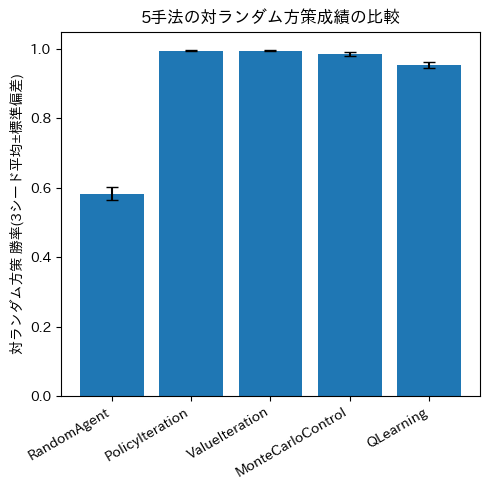

In [8]:
os.makedirs(COMPARISON_DIR, exist_ok=True)
os.makedirs("figures/ex006", exist_ok=True)

summary_rows = []
for m in METHODS:
    # 各手法について, 3シード分のeval.json(対ランダム方策の最終評価)を集めて平均・標準偏差を計算する.
    wins, draws, loses = [], [], []
    for seed in SEEDS:
        with open(os.path.join(m["base_dir"], f"seed_{seed}", "eval.json")) as f:
            r = json.load(f)
        wins.append(r["win_rate"]); draws.append(r["draw_rate"]); loses.append(r["lose_rate"])
    summary_rows.append({
        "label": m["label"],
        "win_mean": float(np.mean(wins)), "win_std": float(np.std(wins)),
        "draw_mean": float(np.mean(draws)), "draw_std": float(np.std(draws)),
        "lose_mean": float(np.mean(loses)), "lose_std": float(np.std(loses)),
    })
    print(
        f"{m['label']:>18s}: win={np.mean(wins):.3f}±{np.std(wins):.3f}, "
        f"draw={np.mean(draws):.3f}±{np.std(draws):.3f}, lose={np.mean(loses):.3f}±{np.std(loses):.3f}"
    )

with open(os.path.join(COMPARISON_DIR, "summary_vs_random.json"), "w") as f:
    json.dump(summary_rows, f, indent=4, ensure_ascii=False)

labels = [row["label"] for row in summary_rows]
win_means = [row["win_mean"] for row in summary_rows]
win_stds = [row["win_std"] for row in summary_rows]

fig, ax = plt.subplots(figsize=(5, 5))
x = np.arange(len(labels))
ax.bar(x, win_means, yerr=win_stds, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("対ランダム方策 勝率(3シード平均±標準偏差)")
ax.set_ylim(0, 1.05)
ax.set_title("5手法の対ランダム方策成績の比較")
fig.tight_layout()
fig.savefig("figures/ex006/win_rate_vs_random.png", dpi=150)
plt.show()


## 「最適な後手」の構築と，それに対する各手法の評価

先手が一様ランダムに打つ場合に最適な後手の方策を，価値反復法(ex003と同じ構造)により新たに構築する．

In [9]:
def o_transition_model(env: "TicTacToeEnv", state: tuple, action: int) -> list:
    """
    後手(O)の意思決定問題における環境モデル p(s'|s,a) を計算する.
    先手(X)が合法手から一様ランダムに選択する固定方策に従うと仮定し,
    Oが行動した後に生じうる遷移を解析的に列挙する. 報酬はOから見た値とする.
    ex002/ex003のtransition_model(Xの手番向け)を, Oの手番向けに書き換えたものである.

    引数:
        env (TicTacToeEnv): 環境.
        state (tuple[int]): Oの手番かつ非終端の状態.
        action (int): Oが選択する行動.
    戻り値:
        list[tuple]: (next_state, prob, reward, done) のリスト. probの総和は1になる.
    """
    # Oが行動した直後の盤面を作り, 決着していれば確率1でそのまま終端に遷移するとみなす.
    assert state[action] == env.EMPTY
    board = list(state)
    board[action] = env.O
    board = tuple(board)
    if env.check_winner(board) == env.O:
        return [(board, 1.0, 1.0, True)]
    if env.is_draw(board):
        return [(board, 1.0, 0.0, True)]

    # 非終端であれば, Xが取りうる全ての合法手について遷移先・報酬・終了フラグを列挙する.
    x_actions = env.get_valid_actions(board)
    prob = 1.0 / len(x_actions)
    outcomes = []
    for a in x_actions:
        b2 = list(board)
        b2[a] = env.X
        b2 = tuple(b2)
        if env.check_winner(b2) == env.X:
            outcomes.append((b2, prob, -1.0, True))
        elif env.is_draw(b2):
            outcomes.append((b2, prob, 0.0, True))
        else:
            outcomes.append((b2, prob, 0.0, False))
    return outcomes


def build_optimal_o_agent(env: "TicTacToeEnv", gamma: float, theta: float, seed: int = 0) -> "TabularQAgent":
    """
    先手(X)が一様ランダムに打つ場合に最適に打つ後手(O)の方策を, 価値反復法により構築する.
    ex003のvalue_iterationと全く同じ構造のベルマン最適方程式を, Oの手番の状態集合と
    o_transition_modelに対して適用する.

    引数:
        env (TicTacToeEnv): 環境.
        gamma (float): 割引率.
        theta (float): 収束判定閾値.
        seed (int): Q値が同点の場合のタイブレークに用いる乱数シード.
    戻り値:
        TabularQAgent: 構築した最適な後手のエージェント(先手Xとの対戦におけるOの役で使用する).
    """
    # 全到達可能状態のうち, 「Oの手番かつ非終端」の状態(Xの手数がOの手数よりちょうど1多い)
    # だけを, 価値反復法の対象として抽出する.
    _, all_states = env.enumerate_states()
    o_states = [
        s for s in all_states
        if env.check_winner(s) == env.EMPTY and not env.is_draw(s)
        and s.count(env.X) == s.count(env.O) + 1
    ]
    # ex003のvalue_iterationと同じ構造の価値反復法を, Oの手番の状態集合に対して実行する.
    V = {s: 0.0 for s in o_states}
    for _ in range(10000):
        delta = 0.0
        new_V = {}
        for s in o_states:
            best_q = -1e18
            for a in env.get_valid_actions(s):
                outcomes = o_transition_model(env, s, a)
                q = sum(p * (r + gamma * (0.0 if done else V[nb])) for nb, p, r, done in outcomes)
                best_q = max(best_q, q)
            new_V[s] = best_q
            delta = max(delta, abs(new_V[s] - V[s]))
        V = new_V
        if delta < theta:
            break

    # 収束した価値関数から, Oの手番の状態だけを埋めたQ値テーブルを構築する.
    Q_array = np.full((env.N_STATES, 9), -np.inf)
    for s in o_states:
        state_id = env.encode_state(s)
        for a in env.get_valid_actions(s):
            outcomes = o_transition_model(env, s, a)
            Q_array[state_id, a] = sum(
                p * (r + gamma * (0.0 if done else V[nb])) for nb, p, r, done in outcomes
            )
    return TabularQAgent(Q_array, seed=seed)


構築した最適な後手に対して5手法(先手)を評価し，勝率・引き分け率・敗率を積み上げ棒グラフで表示する．

       RandomAgent vs 最適な後手: {'win_rate': 0.005, 'draw_rate': 0.067, 'lose_rate': 0.928}
   PolicyIteration vs 最適な後手: {'win_rate': 0.0, 'draw_rate': 1.0, 'lose_rate': 0.0}


    ValueIteration vs 最適な後手: {'win_rate': 0.0, 'draw_rate': 1.0, 'lose_rate': 0.0}
 MonteCarloControl vs 最適な後手: {'win_rate': 0.0, 'draw_rate': 1.0, 'lose_rate': 0.0}


         QLearning vs 最適な後手: {'win_rate': 0.0, 'draw_rate': 0.0, 'lose_rate': 1.0}


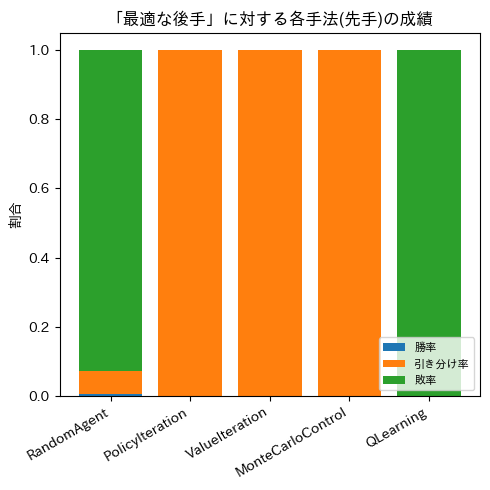

In [10]:
env = TicTacToeEnv()
optimal_o_agent = build_optimal_o_agent(env, GAMMA, THETA)

vs_optimal_rows = []
for m in METHODS:
    agent = load_agent(m["label"], m["base_dir"])
    result = evaluate(agent, opponent=optimal_o_agent, n_episodes=N_EVAL_EPISODES, seed=42)
    vs_optimal_rows.append({"label": m["label"], **result})
    print(f"{m['label']:>18s} vs 最適な後手: {result}")

with open(os.path.join(COMPARISON_DIR, "summary_vs_optimal_opponent.json"), "w") as f:
    json.dump(vs_optimal_rows, f, indent=4, ensure_ascii=False)

labels = [row["label"] for row in vs_optimal_rows]
win = [row["win_rate"] for row in vs_optimal_rows]
draw = [row["draw_rate"] for row in vs_optimal_rows]
lose = [row["lose_rate"] for row in vs_optimal_rows]

fig, ax = plt.subplots(figsize=(5, 5))
x = np.arange(len(labels))
ax.bar(x, win, label="勝率")
ax.bar(x, draw, bottom=win, label="引き分け率")
ax.bar(x, lose, bottom=np.array(win) + np.array(draw), label="敗率")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("割合")
ax.set_ylim(0, 1.05)
ax.set_title("「最適な後手」に対する各手法(先手)の成績")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("figures/ex006/vs_optimal_opponent.png", dpi=150)
plt.show()


## 付録: 人間 vs AI の対人対戦(任意)

ローカルやColab上で対話的に実行したい場合は，下のセルの`RUN_INTERACTIVE`を`True`に変更してください．

In [11]:
# 対戦相手のQ値テーブルのパスを指定してください. 既定ではex005(Q学習)の結果を使用しますが,
# 自分で学習した別のハイパーパラメータ・シードの結果(例えばex001が保存したランダム方策,
# outputs/ex001_tictactoe_baseline/RandomAgent/seed_0/Q.npy)や, Google Driveからアップロード
# した任意の.npyファイル(形状(3**9, 9)のQ値テーブル)のパスに書き換えて使用できます.
Q_PATH = os.path.join(METHODS[-1]["base_dir"], "seed_0", "Q.npy")  # 既定: ex005 QLearning

RUN_INTERACTIVE = False  # Trueにすると対人対戦できます(自動実行時はFalseのままにしてください)
if RUN_INTERACTIVE:
    opponent_agent = TabularQAgent(np.load(Q_PATH))
    print(f"対戦相手: {Q_PATH} が先手(X)です. あなたは後手(O)として対戦します.")
    play_human_vs_ai(opponent_agent)
